In [1]:
from utils import *
%matplotlib inline

In [2]:
ind = 4
row = df.iloc[ind]
save_root = row['save_root']

dFF_ = np.load(save_root + 'cell_dff.npz', allow_pickle=True)['dFF'].astype('float16')
baseline_ = np.load(save_root + 'cell_dff.npz', allow_pickle=True)['baseline'].astype('float16')
A_center = np.load(save_root+'cell_center.npy')
brain_map = np.load(save_root+'Y_ave.npy').astype('float')

_ = np.load(save_root + '/baseline_oxy.npz', allow_pickle=True)
valid_F = _['valid_F']
r_ = _['r_']
p_ = _['p_']
mean_baseline_ = _['mean_baseline_']

locs_cam = np.load(save_root + 'locs_cam.npy')

oxy_ = np.load('../data/O2_internal.npz', allow_pickle=True)['oxy_mean']

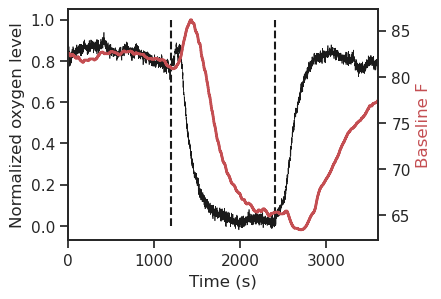

In [3]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(oxy_, '-k', lw=0.5)
ax2.plot(locs_cam/6000, mean_baseline_, '-r', lw=2)
ax1.vlines([1200, 2400], ymin=0, ymax=1.0, colors='k', linestyles='--')
ax1.set_xlim([0, 3600])
ax1.set_ylabel('Normalized oxygen level')
ax2.set_ylabel('Baseline F',color="r")
ax1.set_xlabel('Time (s)')
plt.show()

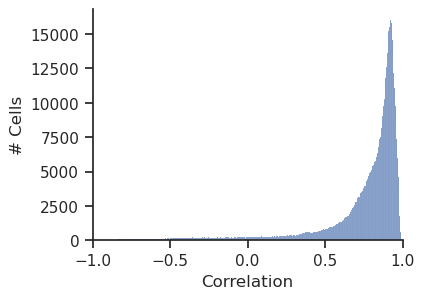

In [4]:
plt.figure()
sns.histplot(r_)
plt.xlim([-1, 1])
plt.xlabel('Correlation')
plt.ylabel('# Cells')
sns.despine()
plt.show()

In [5]:
# idx_ = r_<-0.2
# plt.figure(figsize=(8, 6))
# plt.imshow(brain_map.max(0), cmap=plt.cm.Greys_r, aspect='auto')
# plt.scatter(A_center[valid_F][:, 1][idx_], A_center[valid_F][:, 2][idx_], s=1, c=-r_[idx_], vmax=1, vmin=0)
# plt.axis('off')
# plt.show()

# plt.figure(figsize=(8, 3))
# plt.imshow(brain_map.max(1), cmap=plt.cm.Greys_r, aspect='auto')
# plt.scatter(A_center[valid_F][:, 1][idx_], A_center[valid_F][:, 0][idx_], s=1, c=-r_[idx_], vmax=1, vmin=0)
# plt.axis('off')
# plt.show()

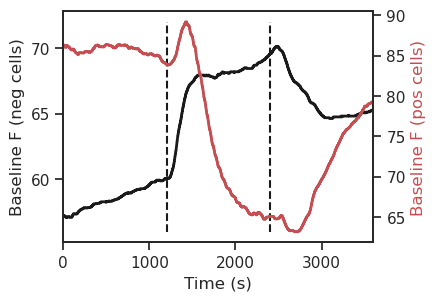

In [6]:
idx_ = r_<-0.2
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(locs_cam/6000, baseline_[valid_F][idx_].mean(axis=0), '-k', lw=2)
idx_ = r_>0.7
ax2.plot(locs_cam/6000, baseline_[valid_F][idx_].mean(axis=0), '-r', lw=2)
ax1.vlines([1200, 2400], ymin=56, ymax=72, colors='k', linestyles='--')
ax1.set_xlim([0, 3600])
ax1.set_ylabel('Baseline F (neg cells)')
ax2.set_ylabel('Baseline F (pos cells)',color="r")
ax1.set_xlabel('Time (s)')
plt.show()